# Baseline Modeling - Radon Risk Prediction with Geology Features at FSA Level

This notebook performs initial exploratory data analysis and preprocessing by merging geology polygons with FSA boundaries, aggregating geology features at the FSA level, and evaluating baseline machine learning models on the merged dataset.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
##### CHANGE DIRECTORIES #####
#shpgeo_dir = Path("/Path/to/the/shpgeo/directory")
#fsa_path = Path("/Path/to/fsa/boundary/dataset/gfsa000a11a_e.shp")
#radon_path = Path("/Path/to/cross-Canada/radon/survey/dataset/radon-concentration.csv")
shpgeo_dir = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/Geological map of Canada/as_1860a/as_1860/CANADA/SHPGEO")
fsa_path = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/FSA data/gfsa000a11a_e/gfsa000a11a_e.shp")
radon_path = Path("/Users/huiyaokuang/OneDrive/Erdos Institute/radon project/data/cross Canada radon survey/radon-concentration.csv")

### 1. Geological map of Canada
Merge all ROX*G.SHP files from the geological map of Canada data

In [3]:
shp_files = list(shpgeo_dir.rglob("ROX*G.SHP"))


In [4]:
gdf_app = gpd.read_file(shpgeo_dir/"APP"/"ROXAPPG.SHP")
print(gdf_app.columns)

Index(['AREA', 'PERIMETER', 'ROXAPP_', 'ROXAPP_ID', 'SYMBOL', 'COMP', 'UNIT',
       'DOMAIN', 'COUNTRY', 'ERA', 'PERIOD', 'EPOCH', 'REWORKAG', 'RXTP',
       'SUBRXTP', 'AGERXTP', 'METGRADE', 'GEOLPROV', 'NAME', 'UNITE',
       'DOMAINE', 'PAYS', 'ERE', 'PERIODE', 'EPOQUE', 'AGETRANS', 'TPRCH',
       'SUBTPRCH', 'AGETPRCH', 'NIVMET', 'PROVGEOL', 'NOM', 'OLDSYMBOL',
       'geometry'],
      dtype='str')


In [5]:
# Drop columns in French
# "ROXAPP_", "ROXAPP_ID", "REWORKAG", "METGRADE", and "NAME" have more than 90% non-null values. So we are not going to keep them.
keep_cols = ["AREA","SYMBOL","UNIT","DOMAIN","COUNTRY","ERA","PERIOD","EPOCH","RXTP","SUBRXTP","AGERXTP","GEOLPROV","geometry"]
gdfs=[]
for rox_shp in shp_files:
    g=gpd.read_file(rox_shp)
    cols = [c for c in keep_cols if c in g.columns]
    g = g[cols].copy()
    g["source_folder"] = rox_shp.parent.name
    gdfs.append(g)

geology_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
print("Merged:", geology_all.shape, "CRS:", geology_all.crs)

Merged: (15833, 14) CRS: EPSG:4267


In [6]:
geology_all.head(3)

,AREA,SYMBOL,UNIT,DOMAIN,COUNTRY,ERA,PERIOD,EPOCH,RXTP,SUBRXTP,AGERXTP,GEOLPROV,geometry,source_folder
0,153550928.0,380,X2g,onshore,Canada,Precambrian,Paleoproterozoic,middle Paleoproterozoic,intrusive rocks,undivided granitoid rocks,Paleoproterozoic intrusive rocks,Churchill Province,"POLYGON ((-78.39017 79.13233, -78.37946 79.133...",CHU
1,87790840.0,380,X2g,onshore,Canada,Precambrian,Paleoproterozoic,middle Paleoproterozoic,intrusive rocks,undivided granitoid rocks,Paleoproterozoic intrusive rocks,Churchill Province,"POLYGON ((-80.18366 79.09895, -80.18062 79.100...",CHU
2,23645288.0,380,X2g,onshore,Canada,Precambrian,Paleoproterozoic,middle Paleoproterozoic,intrusive rocks,undivided granitoid rocks,Paleoproterozoic intrusive rocks,Churchill Province,"POLYGON ((-78.14606 79.19603, -78.16501 79.181...",CHU


In [7]:
geology_all.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 15833 entries, 0 to 15832
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AREA           15833 non-null  float64 
 1   SYMBOL         15833 non-null  int32   
 2   UNIT           15833 non-null  str     
 3   DOMAIN         15833 non-null  str     
 4   COUNTRY        15791 non-null  str     
 5   ERA            15833 non-null  str     
 6   PERIOD         15833 non-null  str     
 7   EPOCH          15833 non-null  str     
 8   RXTP           15833 non-null  str     
 9   SUBRXTP        15833 non-null  str     
 10  AGERXTP        15833 non-null  str     
 11  GEOLPROV       15533 non-null  str     
 12  geometry       15833 non-null  geometry
 13  source_folder  15833 non-null  str     
dtypes: float64(1), geometry(1), int32(1), str(11)
memory usage: 3.9 MB


Remove non-Canada "COUNTRY" entries.

In [8]:
print(geology_all["COUNTRY"].value_counts())
geology_all = geology_all[geology_all["COUNTRY"] == "Canada"].copy()
geology_all = geology_all.drop(columns=["COUNTRY"])


COUNTRY
Canada     14833
USA          896
usa           52
France         8
Iceland        2
Name: count, dtype: int64


In [9]:
geology_all[geology_all["GEOLPROV"].isna()].sample(2)
geology_all["GEOLPROV"] = geology_all["GEOLPROV"].fillna("Unknown")

In [10]:
geology_all.crs

<Geographic 2D CRS: EPSG:4267>
Name: NAD27
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North and central America: Antigua and Barbuda - onshore. Bahamas - onshore plus offshore over internal continental shelf only. Belize - onshore. British Virgin Islands - onshore. Canada onshore - Alberta, British Columbia, Manitoba, New Brunswick, Newfoundland and Labrador, Northwest Territories, Nova Scotia, Nunavut, Ontario, Prince Edward Island, Quebec, Saskatchewan and Yukon - plus offshore east coast. Cuba - onshore and offshore. El Salvador - onshore. Guatemala - onshore. Honduras - onshore. Panama - onshore. Puerto Rico - onshore. Mexico - onshore plus offshore east coast. Nicaragua - onshore. United States (USA) onshore and offshore - Alabama, Alaska, Arizona, Arkansas, California, Colorado, Connecticut, Delaware, Florida, Georgia, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Maryland, 

### 2. Join FSA data

In [11]:
fsa_gdf = gpd.read_file(fsa_path)

In [12]:
print(fsa_gdf.shape, fsa_gdf.crs)
fsa_gdf.head()

(1621, 4) EPSG:4269


,CFSAUID,PRUID,PRNAME,geometry
0,A0A,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,"MULTIPOLYGON (((-53.27283 47.37429, -53.27288 ..."
1,A0B,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,"MULTIPOLYGON (((-53.27864 47.37389, -53.27771 ..."
2,A0C,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,"POLYGON ((-52.99698 48.68359, -52.99591 48.655..."
3,A0E,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,"POLYGON ((-54.42293 48.19427, -54.41571 48.186..."
4,A0G,10,Newfoundland and Labrador / Terre-Neuve-et-Lab...,"POLYGON ((-53.16336 49.41443, -53.19745 49.328..."


The Coordinate Reference System (CRS) of FSA dataset is in EPSG:4269, while the geological dataset is recorded in EPSG:4267. We have to convert them to the same CRS system first (4267 to 4269).

In [13]:
geology_all = geology_all.to_crs("EPSG:4269")

In [14]:
# Join gdf and fsa_gdf using spatial join according to geometry intersections
geo_fsa = gpd.sjoin(
    geology_all,
    fsa_gdf[["CFSAUID", "geometry"]],
    how="inner",
    predicate="intersects"
)
geo_fsa = geo_fsa.drop(columns=["index_right"])
geo_fsa = geo_fsa.rename(columns={"CFSAUID":"FSA"})
geo_fsa.sample(3)

,AREA,SYMBOL,UNIT,DOMAIN,ERA,PERIOD,EPOCH,RXTP,SUBRXTP,AGERXTP,GEOLPROV,geometry,source_folder,FSA
11082,542566912.0,301,2uK,onshore,Mesozoic,Cretaceous,Maastrichtian-Campanian,sedimentary rocks,nonmarine sedimentary rocks,Mesozoic sedimentary rocks,Interior Platform,"POLYGON ((-100.64175 49.00153, -100.63491 49.0...",COR,R0K
4395,114150904.0,215,S,onshore,Paleozoic,Silurian,undivided Silurian,sedimentary rocks,undivided sedimentary rocks,Paleozoic sedimentary rocks,Appalachian Orogen,"POLYGON ((-66.55465 47.62474, -66.54253 47.625...",APP,E8E
15099,15334879.0,220,VWn,onshore,Precambrian,Mesoarchean-Neoarchean,undivided Mesoarchean-Neoarchean,metamorphic rocks,undivided gneiss,Archean metamorphic rocks,Churchill Province,"POLYGON ((-82.37139 69.46289, -82.4231 69.4717...",ARC,X0A


In [15]:
print(geo_fsa.shape)
print(geo_fsa["FSA"].nunique(), "FSAs covered")
print(geo_fsa["FSA"].value_counts())

(21421, 14)
1621 FSAs covered
FSA
X0A    4011
X0E    1216
X0C     775
X0B     731
V0J     603
       ... 
P7K       1
P3C       1
P3A       1
P6B       1
P6C       1
Name: count, Length: 1621, dtype: int64


### 3. Join radon survey data

In [16]:
radon_df = pd.read_csv(radon_path)

In [17]:
print(radon_df.shape)
radon_df = radon_df.drop(
    columns=[
        "Unnamed: 7", "Unnamed: 8", "Unnamed: 9","Unnamed: 10",
        "Unnamed: 11","Unnamed: 12","Health Region2007","HealthRegionCode2007","ResultNumber"
        ]
    ).copy()
radon_df.head(3)


(13815, 13)


,ProvinceTerritory,ForwardSortationAreaCodes,TestDurationInDays,AverageRadonConcentrationInBqPerM3
0,NL,A0A,127.0,20
1,NL,A0A,108.0,36
2,NL,A0E,91.0,<15


Replace "<15" in Average Radon Concentration with 7.5

In [18]:
radon_df["AverageRadonConcentrationInBqPerM3"] = radon_df["AverageRadonConcentrationInBqPerM3"].replace("<15", 7.5).astype(float)

Data cleaning

In [19]:
# Rename radon_df columns
radon_df = radon_df.rename(columns={"ForwardSortationAreaCodes":"FSA"})

In [20]:
#pd.set_option("display.max_rows", None)
print(radon_df["FSA"].value_counts())  # "*" means some data has been removed in order to protect the identity of study participants.
radon_df = radon_df[radon_df["FSA"] != "*"].copy()

FSA
*      247
Y1A    179
T0H    175
G8P    143
S0J    136
      ... 
V7R      2
V8N      2
V8R      2
V8X      2
V9S      2
Name: count, Length: 1015, dtype: int64


In [21]:
# radon_df group by FSA
radon_fsa = radon_df.groupby("FSA").agg(
    mean_radon = ("AverageRadonConcentrationInBqPerM3","mean"),
    median_radon = ("AverageRadonConcentrationInBqPerM3","median"),
    mean_duration = ("TestDurationInDays","mean"),
    n_tests = ("AverageRadonConcentrationInBqPerM3","count"),
    Province = ("ProvinceTerritory", "first")
).reset_index()

In [22]:
radon_fsa.head(5)

,FSA,mean_radon,median_radon,mean_duration,n_tests,Province
0,A0A,69.230769,27.0,104.923077,13,NL
1,A0B,48.833333,17.0,100.666667,3,NL
2,A0C,53.900000,31.0,99.400000,5,NL
3,A0E,31.588235,21.0,96.235294,17,NL
4,A0G,70.769231,24.0,96.553846,65,NL


In [23]:
radon_fsa.isna().sum()


FSA              0
mean_radon       0
median_radon     0
mean_duration    0
n_tests          0
Province         0
dtype: int64

Merge radon_fsa with geo_fsa

In [24]:
df_fsa = geo_fsa.merge(radon_fsa, on="FSA", how="left")

In [25]:
df_fsa.isna().sum()

AREA                0
SYMBOL              0
UNIT                0
DOMAIN              0
ERA                 0
PERIOD              0
EPOCH               0
RXTP                0
SUBRXTP             0
AGERXTP             0
GEOLPROV            0
geometry            0
source_folder       0
FSA                 0
mean_radon       1497
median_radon     1497
mean_duration    1497
n_tests          1497
Province         1497
dtype: int64

In [26]:
df_fsa.sample(3)

,AREA,SYMBOL,UNIT,DOMAIN,ERA,PERIOD,EPOCH,RXTP,SUBRXTP,AGERXTP,GEOLPROV,geometry,source_folder,FSA,mean_radon,median_radon,mean_duration,n_tests,Province
14332,1.246616e+08,390,MKq,onshore,Mesozoic,Cretaceous,middle Cretaceous,intrusive rocks,"quartz monzonite, granite",Mesozoic intrusive rocks,Cordilleran Orogen,"POLYGON ((-118.86121 51.32589, -118.84402 51.3...",COR,V0E,88.425,66.00,95.900000,40.0,BC
12758,7.153960e+10,310,pT,onshore,Cenozoic,Tertiary,Paleogene,sedimentary rocks,nonmarine sedimentary rocks,Cenozoic sedimentary rocks,Interior Platform,"POLYGON ((-117.17317 54.30697, -117.12486 54.3...",COR,T4C,NaN,NaN,NaN,NaN,NaN
7274,1.445802e+10,215,uS,onshore,Paleozoic,Silurian,upper Silurian,sedimentary rocks,undivided sedimentary rocks,Paleozoic sedimentary rocks,St. Lawrence Platform,"POLYGON ((-81.53581 44.41588, -81.53127 44.420...",APP,L2R,11.750,11.75,101.666667,6.0,ON


Save df_fsa to .csv

In [27]:
df_fsa = df_fsa.drop(columns=["geometry"])   # Drop geometry to save memory
df_fsa.to_csv("df_fsa.csv", index="False")

### 4. Baseline modeling

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


In [29]:
df_model = df_fsa.dropna(subset=["mean_radon", "median_radon", "n_tests", "mean_duration"]).copy()

In [30]:
threshold = 200
df_model["high_risk"] = (df_model["mean_radon"] >= threshold).astype(int)

print(df_model["high_risk"].value_counts(normalize=True))
print(df_model.shape)

high_risk
0    0.979974
1    0.020026
Name: proportion, dtype: float64
(19924, 19)


In [31]:
y = df_model["high_risk"]
x_col =["DOMAIN", "ERA", "PERIOD", "EPOCH", "RXTP", "SUBRXTP", "AGERXTP", "GEOLPROV"]
X = df_model[x_col]

In [32]:
cat_cols = x_col
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [33]:
# Dummy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy="most_frequent")

scores = cross_val_score(dummy, np.zeros((len(y), 1)), y, cv=cv, scoring="roc_auc")
print("Dummy ROC-AUC:", scores.mean(), "+/-", scores.std())


Dummy ROC-AUC: 0.5 +/- 0.0


In [34]:
# Logistic Regression
logreg_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

scores = cross_val_score(logreg_model, X, y, cv=cv, scoring="roc_auc")
print("LogReg ROC-AUC:", scores.mean(), "+/-", scores.std())

LogReg ROC-AUC: 0.8862812646882446 +/- 0.009813512891592789


In [35]:
# Random Forest
rf_model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")
print("RF ROC-AUC:", scores.mean(), "+/-", scores.std())

RF ROC-AUC: 0.8777775004457122 +/- 0.023499635612741265


In [36]:
# Precision-Recall AUC
scores = cross_val_score(logreg_model, X, y, cv=cv, scoring="average_precision")
print("LogReg PR-AUC:", scores.mean(), "+/-", scores.std())

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="average_precision")
print("RF PR-AUC:", scores.mean(), "+/-", scores.std())


LogReg PR-AUC: 0.15244439519593359 +/- 0.01609451662005559
RF PR-AUC: 0.18544327076953646 +/- 0.025588192079517846


In [37]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

models = {
    "Dummy": dummy,
    "LogReg": logreg_model,
    "RandomForest": rf_model
}

rows = []

for name, model in models.items():
    if name == "Dummy":
        roc_scores = cross_val_score(model, np.zeros((len(y), 1)), y, cv=cv, scoring="roc_auc")
        pr_scores  = cross_val_score(model, np.zeros((len(y), 1)), y, cv=cv, scoring="average_precision")
    else:
        roc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        pr_scores  = cross_val_score(model, X, y, cv=cv, scoring="average_precision")
    rows.append({
        "model": name,
        "roc_auc_mean": roc_scores.mean(),
        "roc_auc_std": roc_scores.std(),
        "pr_auc_mean": pr_scores.mean(),
        "pr_auc_std": pr_scores.std()
    })

results = pd.DataFrame(rows)
results

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Dummy,0.500000,0.000000,0.020026,0.000098
1,LogReg,0.886281,0.009814,0.152444,0.016095
2,RandomForest,0.877778,0.023500,0.185443,0.025588


### 5. Visualization of data

##### （a) Radon concentration: mean vs. median?

In [38]:
radon_df["AverageRadonConcentrationInBqPerM3"].nlargest(10)

7213     5657.0
1936     5590.0
11609    2941.0
3374     2923.0
4664     2741.0
1241     2692.0
2015     2466.0
1052     2448.0
13550    2357.0
5855     2307.0
Name: AverageRadonConcentrationInBqPerM3, dtype: float64

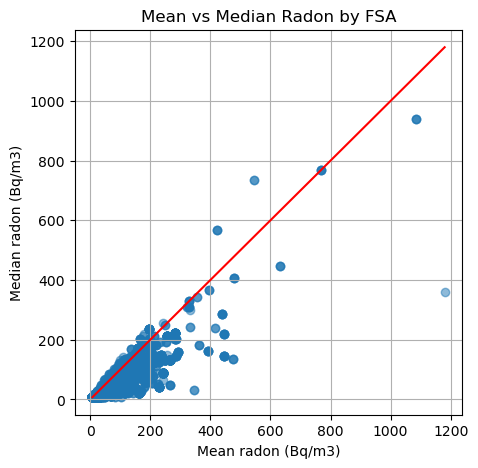

In [39]:
plt.figure(figsize=(5,5))
plt.scatter(df_fsa["mean_radon"], df_fsa["median_radon"], alpha=0.5)
min_val = min(df_fsa["mean_radon"].min(), df_fsa["median_radon"].min())
max_val = max(df_fsa["mean_radon"].max(), df_fsa["median_radon"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r", label="y = x")
plt.xlabel("Mean radon (Bq/m3)")
plt.ylabel("Median radon (Bq/m3)")
plt.title("Mean vs Median Radon by FSA")
plt.grid(True)
plt.show()

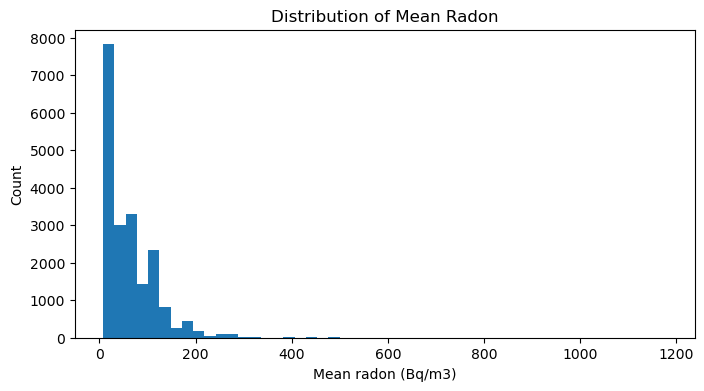

In [40]:
plt.figure(figsize=(8,4))
plt.hist(df_fsa["mean_radon"], bins=50)
plt.xlabel("Mean radon (Bq/m3)")
plt.ylabel("Count")
plt.title("Distribution of Mean Radon")
plt.show()


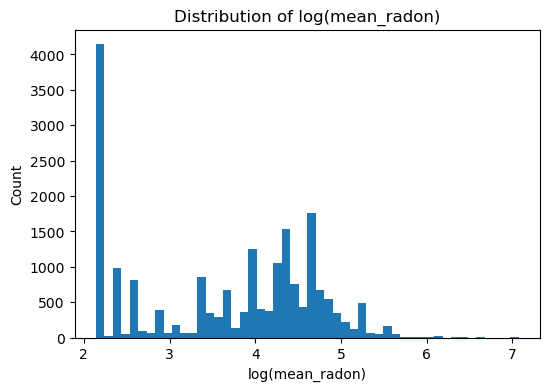

In [41]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df_fsa["mean_radon"]), bins=50)
plt.xlabel("log(mean_radon)")
plt.ylabel("Count")
plt.title("Distribution of log(mean_radon)")
plt.show()


##### （b) High-risk rate by geology categories

In [42]:
baseline_rate = df_model["high_risk"].mean()

def plot_high_risk_rate_by_category(df, col, top_n=15, min_samples=30):
    # Plot high-risk rate by a categorical feature column. Filters out categories with too few samples.
    summary = (
        df.groupby(col)["high_risk"]
        .agg(n_samples="count", high_risk_rate="mean")
        .reset_index()
    )
    summary = summary[summary["n_samples"] >= min_samples]
    summary = summary.sort_values("high_risk_rate", ascending=False).head(top_n) 

    plt.figure(figsize=(5, 4))
    plt.barh(summary[col].astype(str), summary["high_risk_rate"])
    plt.axvline(baseline_rate, color="red", linestyle="--", label=f"Baseline rate = {baseline_rate:.3f}")
    plt.xlabel("High-risk rate")
    plt.ylabel(col)
    plt.title(f"High-risk rate by {col} (Top {top_n}, min_samples={min_samples})")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()

    return summary


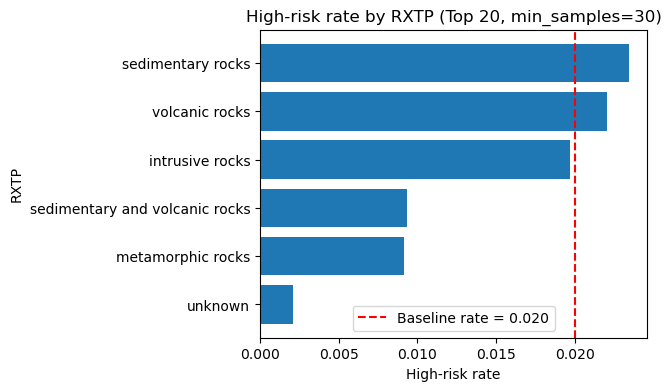

,RXTP,n_samples,high_risk_rate
3,sedimentary rocks,9509,0.023451
5,volcanic rocks,2356,0.022071
0,intrusive rocks,5077,0.019697
2,sedimentary and volcanic rocks,427,0.009368
1,metamorphic rocks,2079,0.009139
4,unknown,476,0.002101


In [43]:
# RXTP
summary_rxtp = plot_high_risk_rate_by_category(df_model, "RXTP", top_n=20, min_samples=30)
summary_rxtp

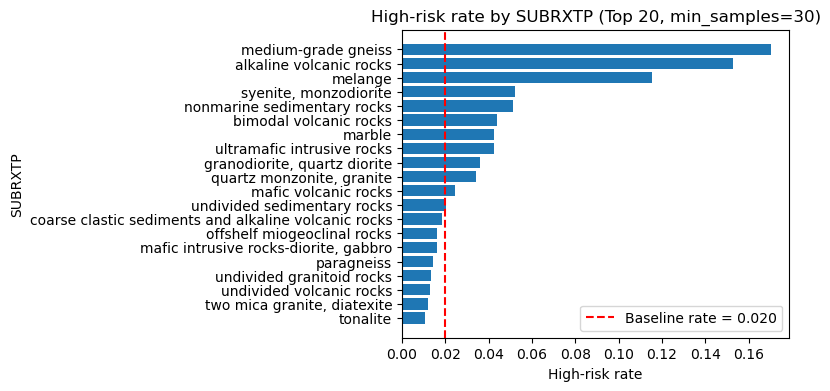

,SUBRXTP,n_samples,high_risk_rate
23,medium-grade gneiss,47,0.170213
2,alkaline volcanic rocks,59,0.152542
24,melange,52,0.115385
35,"syenite, monzodiorite",192,0.052083
25,nonmarine sedimentary rocks,882,0.051020
5,bimodal volcanic rocks,183,0.043716
22,marble,47,0.042553
39,ultramafic intrusive rocks,94,0.042553
16,"granodiorite, quartz diorite",837,0.035842
31,"quartz monzonite, granite",323,0.034056


In [44]:
# SUBRXTP
summary_subrxtp = plot_high_risk_rate_by_category(df_model, "SUBRXTP", top_n=20, min_samples=30)
summary_subrxtp

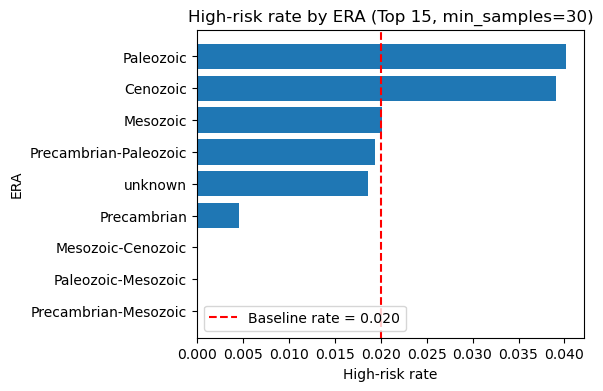

,ERA,n_samples,high_risk_rate
3,Paleozoic,5928,0.040148
0,Cenozoic,895,0.039106
1,Mesozoic,3480,0.020115
7,Precambrian-Paleozoic,361,0.019391
8,unknown,538,0.018587
5,Precambrian,8439,0.004621
2,Mesozoic-Cenozoic,155,0.000000
4,Paleozoic-Mesozoic,96,0.000000
6,Precambrian-Mesozoic,32,0.000000


In [45]:
# ERA
summary_era = plot_high_risk_rate_by_category(df_model, "ERA", top_n=15, min_samples=30)
summary_era

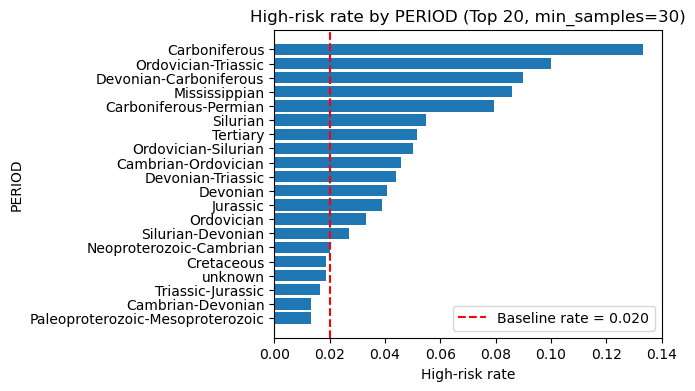

,PERIOD,n_samples,high_risk_rate
6,Carboniferous,270,0.133333
38,Ordovician-Triassic,30,0.100000
11,Devonian-Carboniferous,78,0.089744
22,Mississippian,93,0.086022
7,Carboniferous-Permian,189,0.079365
51,Silurian,457,0.054705
53,Tertiary,680,0.051471
37,Ordovician-Silurian,260,0.050000
4,Cambrian-Ordovician,763,0.045872
15,Devonian-Triassic,68,0.044118


In [46]:
# PERIOD
summary_period = plot_high_risk_rate_by_category(df_model, "PERIOD", top_n=20, min_samples=30)
summary_period

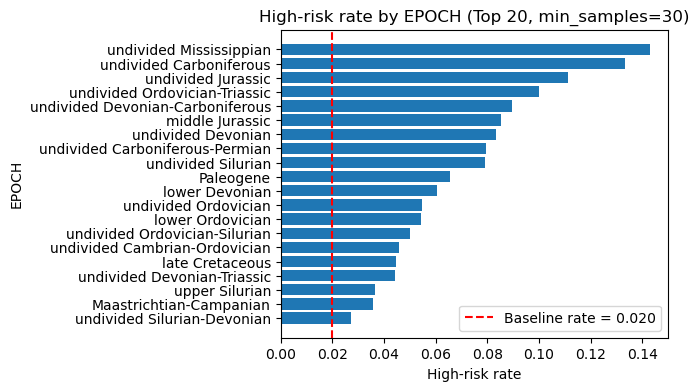

,EPOCH,n_samples,high_risk_rate
64,undivided Mississippian,56,0.142857
46,undivided Carboniferous,270,0.133333
57,undivided Jurassic,63,0.111111
80,undivided Ordovician-Triassic,30,0.100000
52,undivided Devonian-Carboniferous,78,0.089744
30,middle Jurassic,188,0.085106
51,undivided Devonian,156,0.083333
47,undivided Carboniferous-Permian,189,0.079365
96,undivided Silurian,240,0.079167
6,Paleogene,457,0.065646


In [47]:
# EPOCH
summary_epoch = plot_high_risk_rate_by_category(df_model, "EPOCH", top_n=20, min_samples=30)
summary_epoch

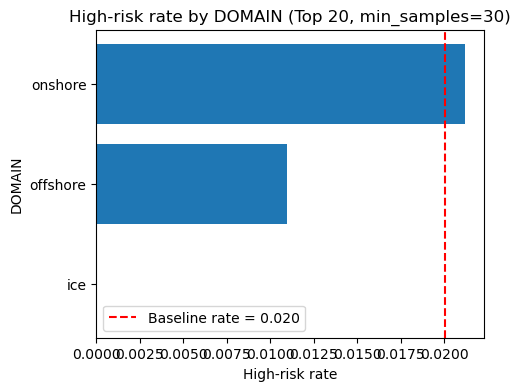

,DOMAIN,n_samples,high_risk_rate
2,onshore,17690,0.021198
1,offshore,2187,0.010974
0,ice,47,0.000000


In [48]:
# DOMAIN
summary_domain = plot_high_risk_rate_by_category(df_model, "DOMAIN", top_n=20, min_samples=30)
summary_domain

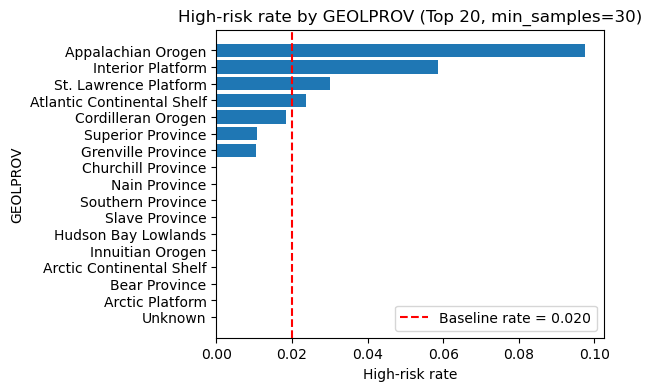

,GEOLPROV,n_samples,high_risk_rate
0,Appalachian Orogen,1998,0.097598
11,Interior Platform,769,0.058518
17,St. Lawrence Platform,1035,0.029952
3,Atlantic Continental Shelf,42,0.023810
7,Cordilleran Orogen,5020,0.018526
18,Superior Province,1946,0.010791
8,Grenville Province,1151,0.010426
6,Churchill Province,3736,0.000268
12,Nain Province,201,0.000000
16,Southern Province,142,0.000000


In [49]:
# GEOGEOLPROV
summary_geolprov = plot_high_risk_rate_by_category(df_model, "GEOLPROV", top_n=20, min_samples=30)
summary_geolprov

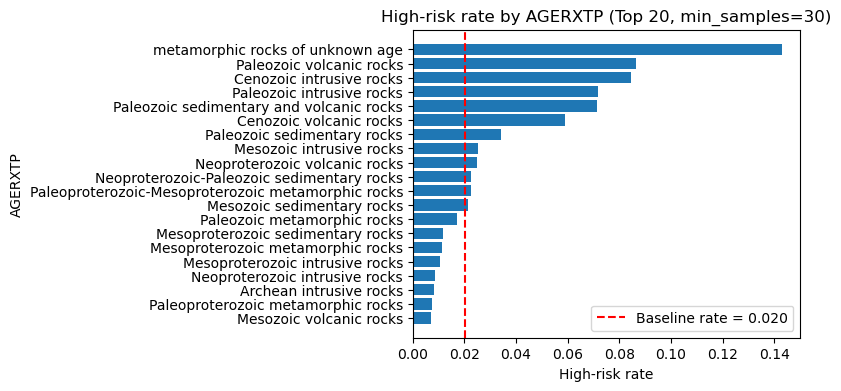

,AGERXTP,n_samples,high_risk_rate
61,metamorphic rocks of unknown age,63,0.142857
56,Paleozoic volcanic rocks,312,0.086538
11,Cenozoic intrusive rocks,213,0.084507
52,Paleozoic intrusive rocks,503,0.071571
54,Paleozoic sedimentary and volcanic rocks,42,0.071429
14,Cenozoic volcanic rocks,238,0.058824
55,Paleozoic sedimentary rocks,5007,0.034152
22,Mesozoic intrusive rocks,1023,0.025415
34,Neoproterozoic volcanic rocks,80,0.025000
40,Neoproterozoic-Paleozoic sedimentary rocks,311,0.022508


In [50]:
# AGERXTP
summary_agerxtp = plot_high_risk_rate_by_category(df_model, "AGERXTP", top_n=20, min_samples=30)
summary_agerxtp